# **Import Libraries**


In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


from sklearn.linear_model import Ridge,Lasso
from sklearn.model_selection import GridSearchCV


# **Mount Drive**

In [101]:
from google.colab import drive
drive.mount('/content/drive')
print('.........drive mounted successfully!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
.........drive mounted successfully!


# **Load Data**

In [102]:
df=pd.read_csv('/content/drive/MyDrive/Projects/House Price Prediction/Data/train.csv')
print('.........data loaded successfully!')

.........data loaded successfully!


# **EDA**

In [103]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [105]:
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


### Checking skweness on target column

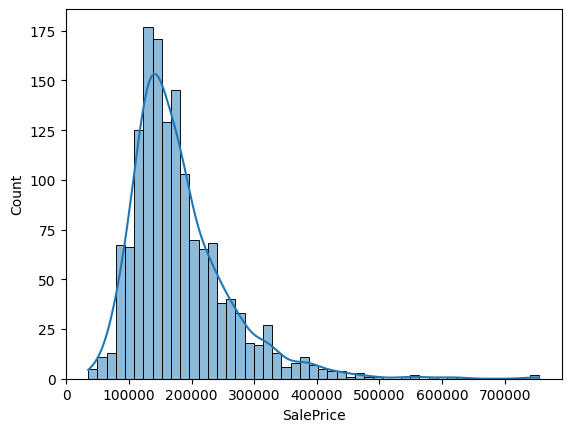

In [106]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

## Missing Values Analysis

In [107]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


### Handling missing values

In [108]:
df.drop(['Alley','PoolQC','Fence','MiscFeature'], axis=1, inplace=True)

In [109]:
# df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)
# df['GarageYrBlt'].fillna(df['GarageYrBlt'].median(), inplace=True)
df.fillna({
    'LotFrontage': df['LotFrontage'].median(),
    'GarageYrBlt': df['GarageYrBlt'].median(),
    'MasVnrArea' : 0
}, inplace=True)
# df['MasVnrArea'].fillna(0, inplace=True)

In [110]:
cat_cols = ['BsmtQual','BsmtCond','BsmtExposure','GarageType','GarageFinish']

for col in cat_cols:
    df[col] = df[col].fillna('None')





In [111]:
cols_none = ['FireplaceQu','GarageQual','GarageCond','BsmtFinType1','BsmtFinType2']
for col in cols_none:
    df[col] = df[col].fillna('None')

In [112]:
# df['MasVnrType'].fillna(df['MasVnrType'].mode()[0], inplace=True)
# df['Electrical'].fillna(df['Electrical'].mode()[0], inplace=True)

df.fillna({
    'MasVnrType': df['MasVnrType'].mode()[0],
    'Electrical': df['Electrical'].mode()[0],
}, inplace=True)

In [113]:
null_values=df.isnull().sum().sum()
print(f'remaining missing columns {null_values}')
if null_values ==0:
   print('.....Cleaned Missing values successfully.........')

remaining missing columns 0
.....Cleaned Missing values successfully.........


# **Correlation Analysis**

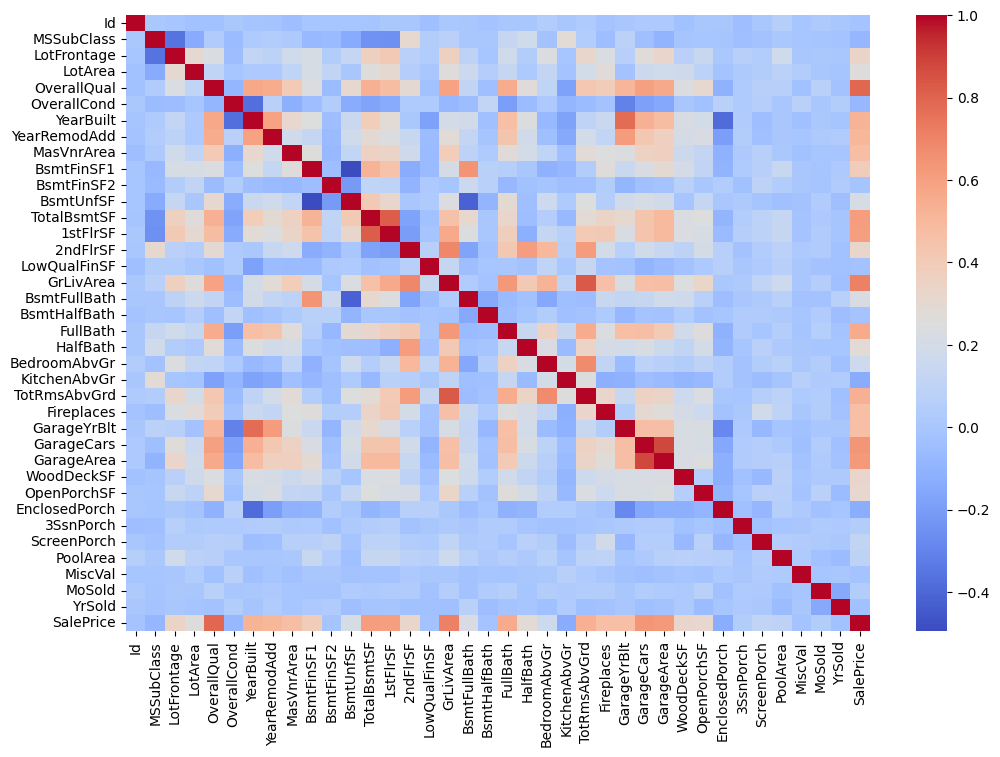

In [114]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [115]:
important_features=corr['SalePrice'].sort_values(ascending=False).head(10)
important_features

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [116]:
names=important_features.index.tolist()

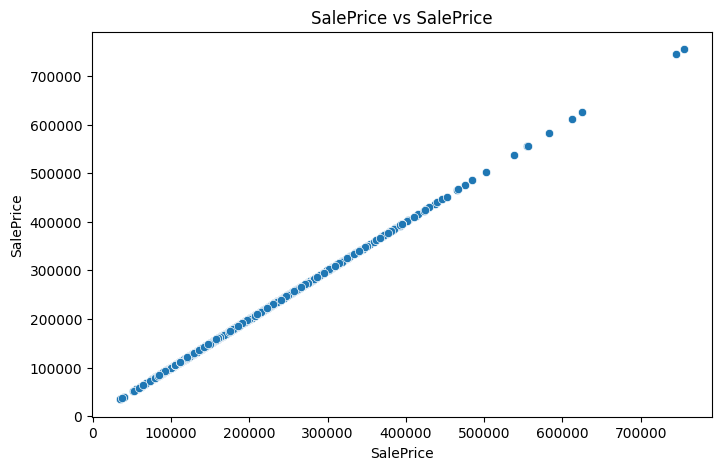

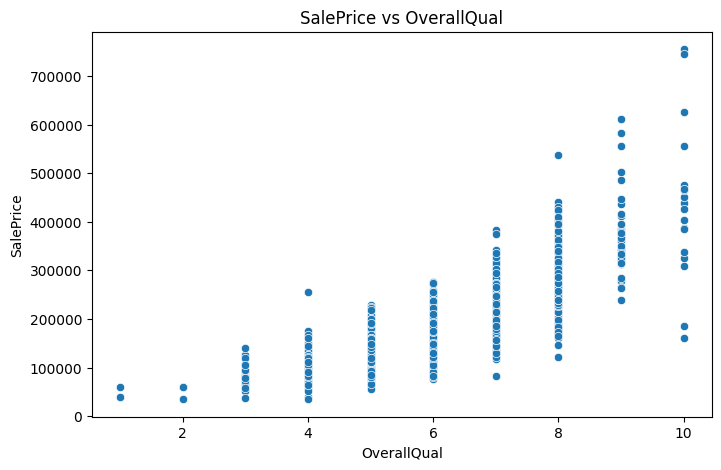

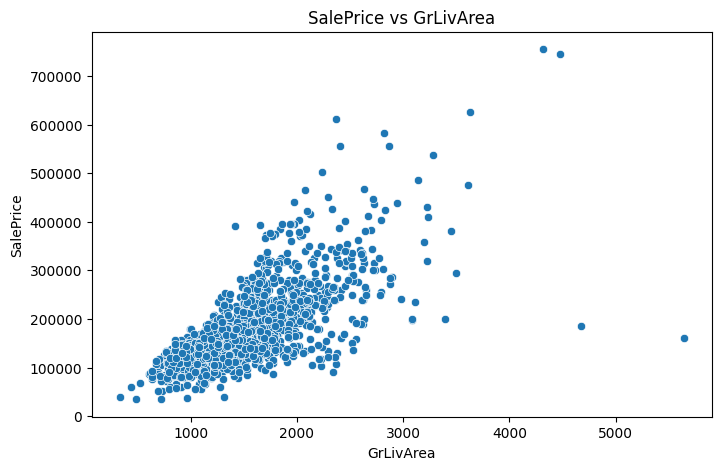

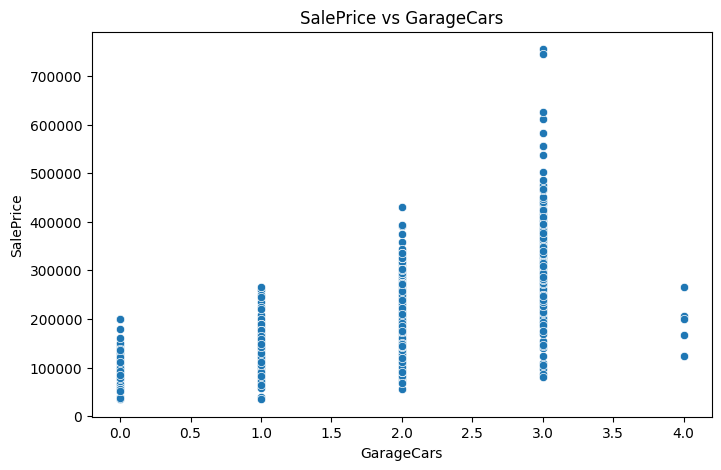

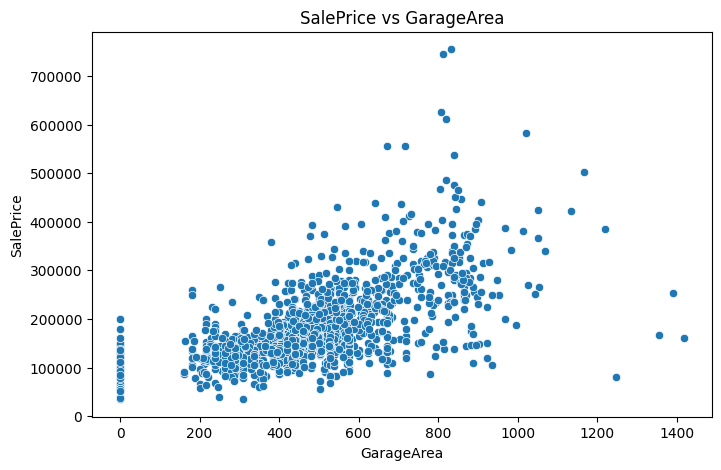

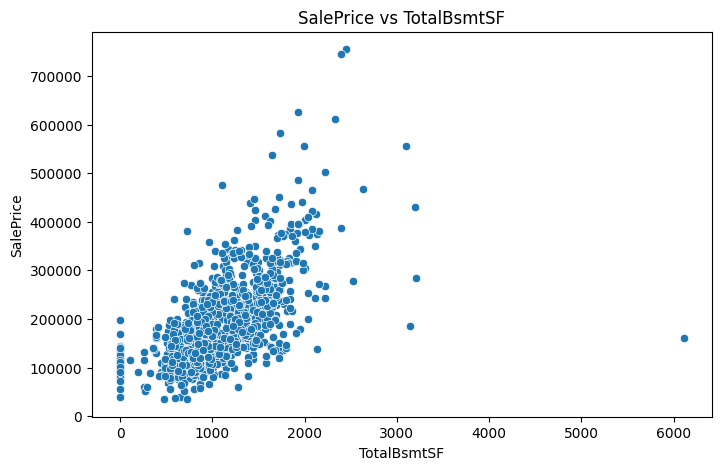

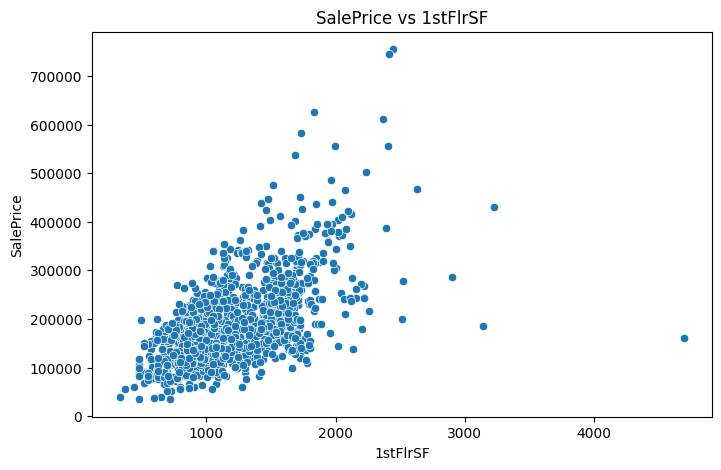

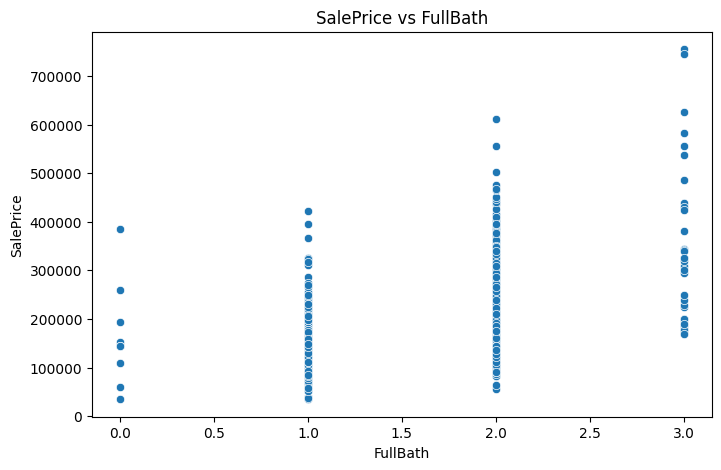

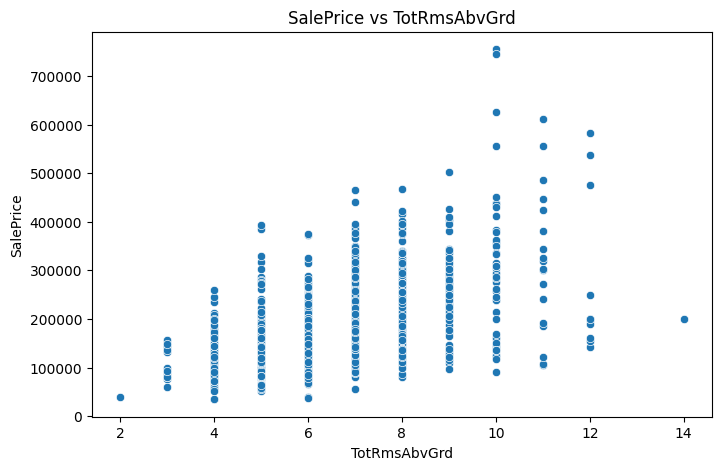

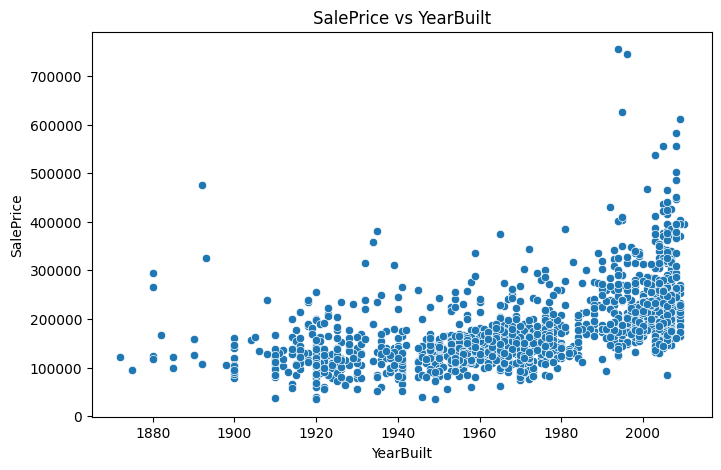

In [117]:
for i in names:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=i, y='SalePrice', data=df)
    plt.title(f'SalePrice vs {i}')
    plt.show()

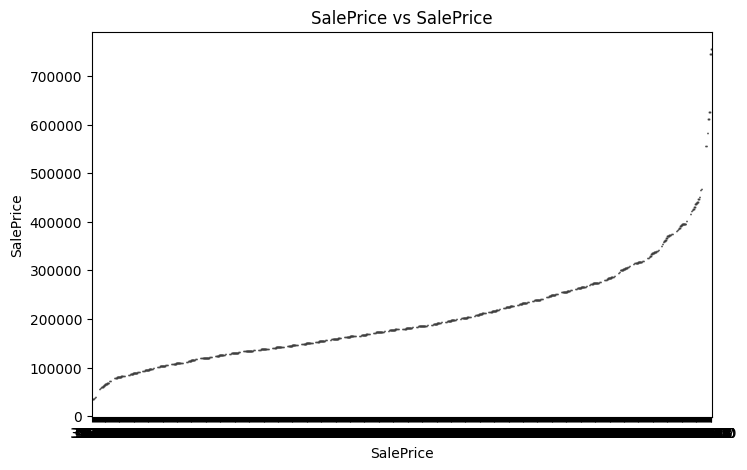

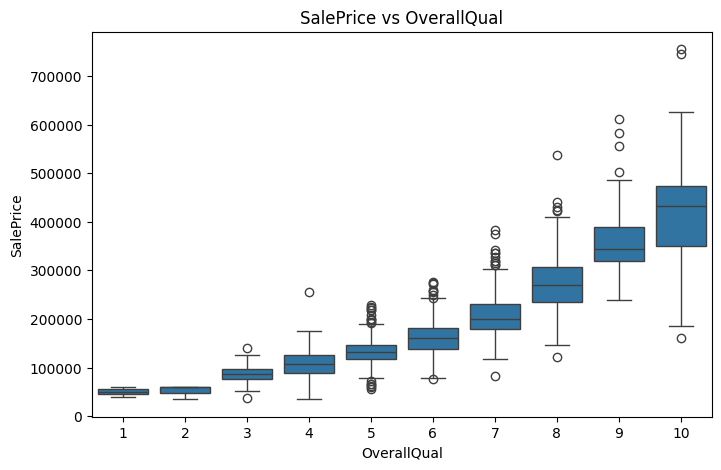

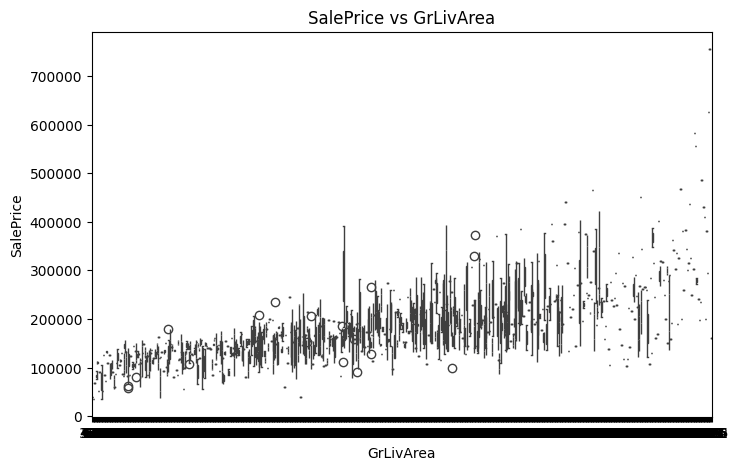

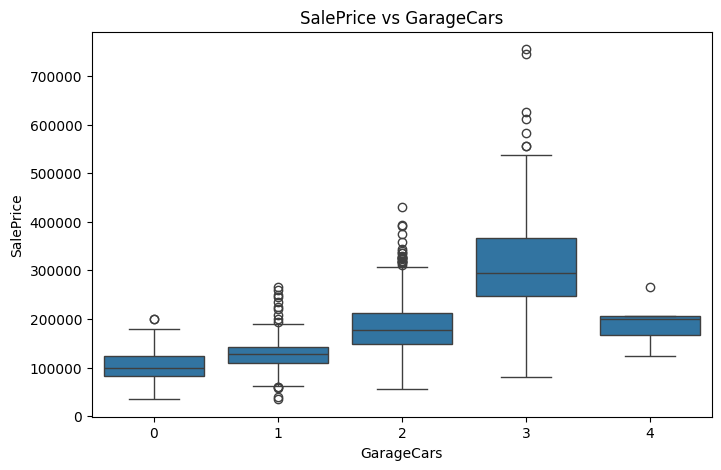

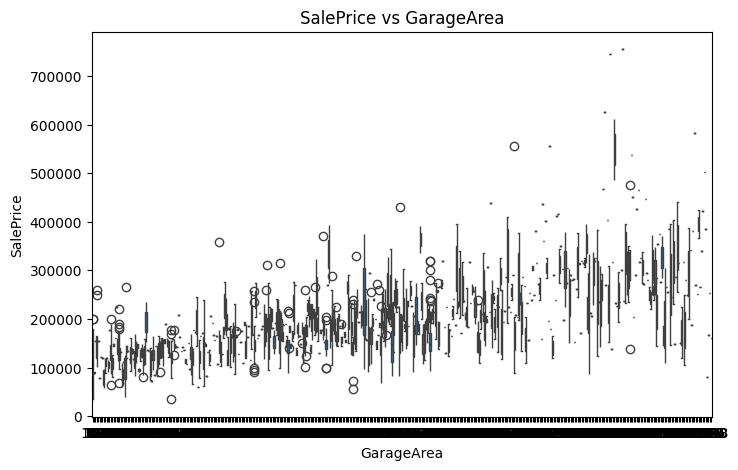

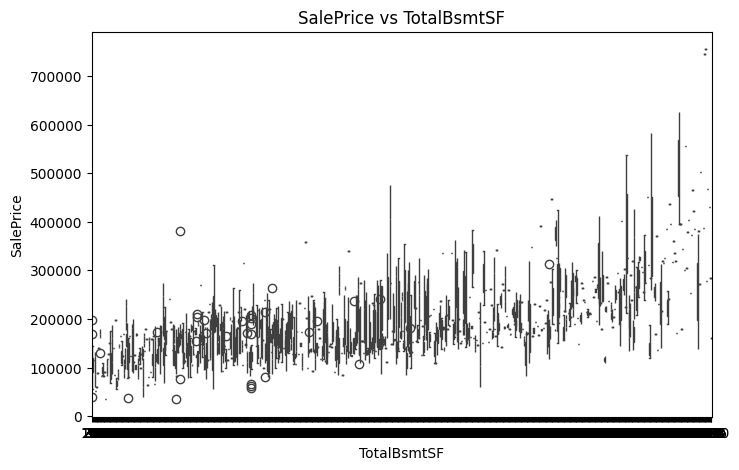

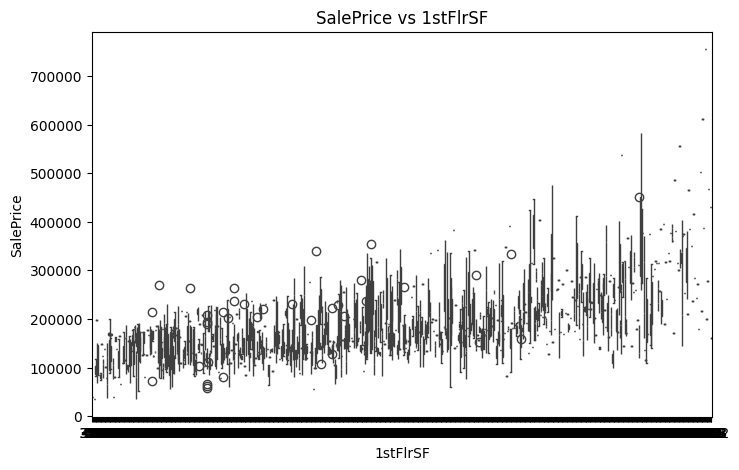

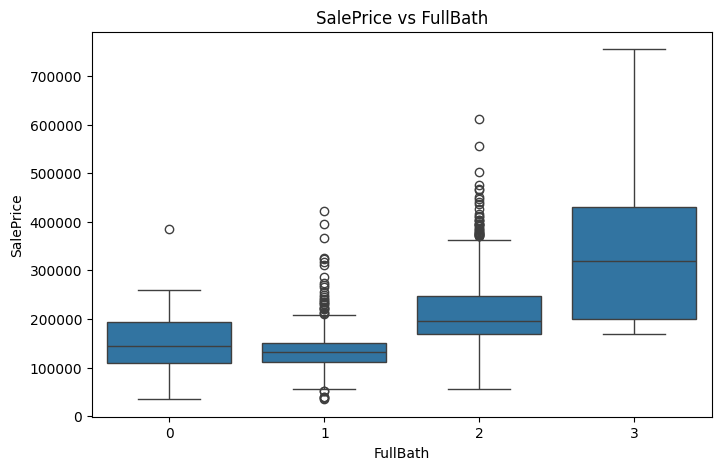

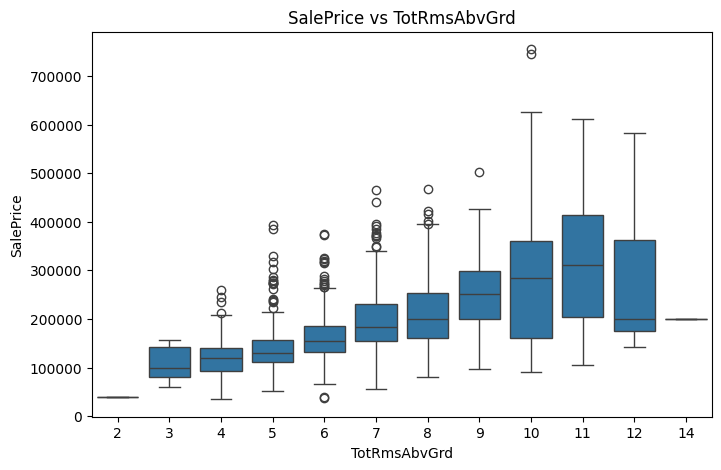

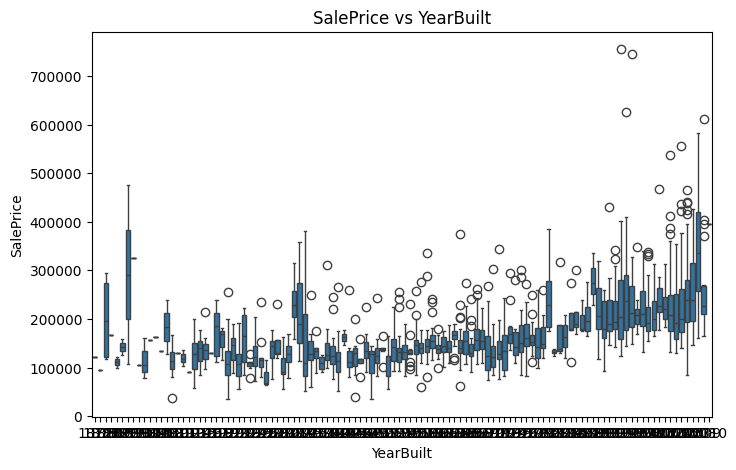

In [118]:
for i in names:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=i, y='SalePrice', data=df)
    plt.title(f'SalePrice vs {i}')
    plt.show()

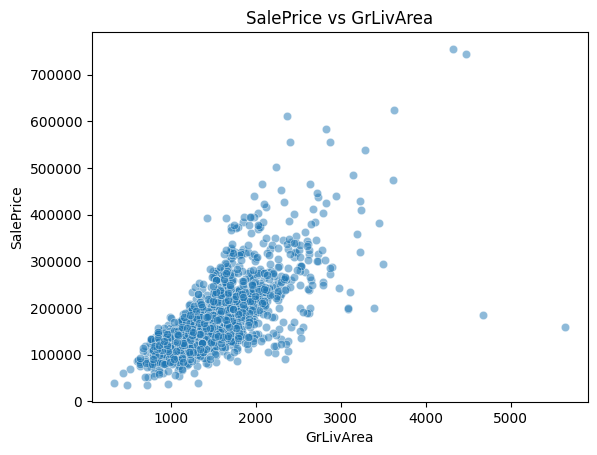

In [119]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, alpha=0.5)
plt.title(f'SalePrice vs GrLivArea')
plt.show()

# **Remove Extreme + Unrealistic Ones**

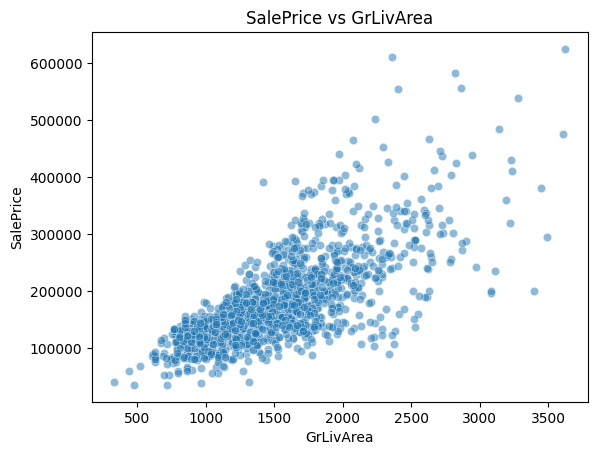

In [120]:
df = df[df['GrLivArea'] < 4000]
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, alpha=0.5)
plt.title(f'SalePrice vs GrLivArea')
plt.show()

# **Fixing Skewness**

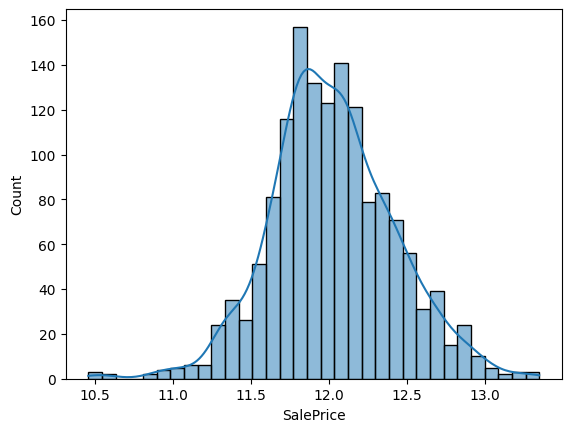

In [121]:
df['SalePrice'] = np.log1p(df['SalePrice'])
sns.histplot(df['SalePrice'], kde=True)
plt.show()

# **ML phase**

## **Droping Useless columns**

In [122]:
# cols_to_drop = [
#     'Id',
#     'Street', 'Utilities', 'Condition2', 'RoofMatl',
#     'MSSubClass', 'OverallCond', 'BsmtFinSF2',
#     'LowQualFinSF', '3SsnPorch', 'PoolArea', 'MiscVal'
# ]

# df.drop(cols_to_drop, axis=1, inplace=True)
df.drop('Id', axis=1, inplace=True)

## **Feature Encoding**

In [123]:
df = pd.get_dummies(df, drop_first=True)

## **Train Test Split**

In [126]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Linear Regression model**

In [128]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [130]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

0.13023915515397444


## **Ridge Regression**

In [132]:
ridge = Ridge()

params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_cv = GridSearchCV(ridge, params, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train, y_train)

ridge_pred = ridge_cv.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_pred))
print(ridge_cv.best_params_)
print(rmse_ridge)


{'alpha': 10}
0.12399761927340398


## **Lasso Regreesion**

In [134]:
lasso = Lasso()

lasso_cv = GridSearchCV(lasso, params, scoring='neg_mean_squared_error', cv=5)
lasso_cv.fit(X_train, y_train)

lasso_pred = lasso_cv.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_pred))
print(lasso_cv.best_params_)
print(rmse_lasso)

{'alpha': 0.01}
0.13907347517611474


In [137]:
scores={
    'Linear Regression' : rmse,
    'Ridge' : rmse_ridge,
    'Lasso' : rmse_lasso
}
scores_df = pd.DataFrame(scores, index=[0])

In [138]:
scores_df

,Linear Regression,Ridge,Lasso
0,0.130239,0.123998,0.139073
